# BaloMS spatial transcriptomics analysis with spatialrs

End-to-end analysis of Balo's concentric sclerosis (MS) brain tissue using the `spatialrs` Python bindings.

**Dataset:** `baloMS_companion.ready.h5ad`  
**Cells:** 71 721 (Balo-1: 30 953, Balo-2: 40 768)  
**Genes:** 5 101 (Xenium panel)  
**Cell types:** 12 (Leiden 1.0 clusters)

**Pipeline**
1. Load data & extract components  
2. Preprocessing (normalize → log1p → filter → HVG detection)  
3. Spatial graph QC — choose radius  
4. Cell-type interaction enrichment (per sample)  
5. Neighbourhood composition  
6. Moran's I — spatial autocorrelation of scVI components  
7. NMF on HVGs  
8. GMM spatial niche detection  
9. Spatial maps

In [18]:
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import scipy.sparse as sp

import spatialrs  # pip install maturin && maturin develop (from repo root)

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

## 1. Load data

In [2]:
H5AD = '/Users/chrislangseth/Downloads/baloMS_companion.ready.h5ad'
adata = ad.read_h5ad(H5AD)
print(adata)

AnnData object with n_obs × n_vars = 71721 × 5101
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'sample_id', 'n_genes_by_counts', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_1.5', 'leiden_2', 'gmm_mana_5', 'gmm_mana_8', 'gmm_mana_10', 'gmm_mana_12', 'gmm_mana_15', 'gmm_mana_20', 'leiden_0.5_names', 'leiden_1_names', 'leiden_2_names', 'leiden_2_names_sub'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'ACSL1_continuous', 'APOE_continuous', 'CCL5_continuous', 'CHIT1_continuous', 'PADI4_continuous', 'SPP1_continuous', 'X_mana_gauss_params', 'gmm_mana_10_colors', 'gmm_mana_15_colors', 'gmm_mana_20_colors', 'gmm_m

In [3]:
# Core arrays used throughout
coords    = adata.obsm['spatial'].astype(np.float64)          # N × 2
barcodes  = list(adata.obs_names)
cell_types = list(adata.obs['leiden_1_names'])
sample_ids = np.array(adata.obs['sample_id'])
scvi       = adata.obsm['X_scVI'].astype(np.float64)          # N × 10

# Per-sample masks
mask = {s: sample_ids == s for s in np.unique(sample_ids)}

print('Samples:', {s: m.sum() for s, m in mask.items()})
print('Cell types:', sorted(set(cell_types)))

Samples: {'Balo-1': np.int64(30953), 'Balo-2': np.int64(40768)}
Cell types: ['Astrocytes Homeostatic', 'Endothelial cells', 'Excitatory Neurons', 'Inhibitory neurons', 'Microglia Disease Associated', 'Microglia Foamy', 'Mix', 'Neurons', 'OPCs', 'Oligodendrocytes', 'Pericytes/Perivascular?', 'Reactive astrocytes']


## 2. Preprocessing with spatialrs

The companion h5ad already carries a `counts` layer (raw UMI) and a log-normalised `X`.
This section shows how you'd preprocess a **raw counts matrix** from scratch using `spatialrs`.

In [4]:
# --- Load raw counts (sparse CSR → dense float64) ---
counts_raw = adata.layers['counts']
if sp.issparse(counts_raw):
    counts_raw = counts_raw.toarray()
counts_raw = np.asarray(counts_raw).astype(np.float64)

print(f'Raw counts: {counts_raw.shape}, dtype={counts_raw.dtype}')
print(f'Mean counts per cell: {counts_raw.sum(axis=1).mean():.1f}')

Raw counts: (71721, 5101), dtype=float64
Mean counts per cell: 501.4


In [5]:
# --- Filter cells: keep cells with >= 50 detected genes and >= 100 counts ---
cell_mask = spatialrs.filter_cells(counts_raw, min_genes=50, min_counts=100.0)
print(f'Cells passing QC: {sum(cell_mask)} / {len(cell_mask)}')

Cells passing QC: 61449 / 71721


In [6]:
# --- Filter genes: keep genes in >= 10 cells ---
gene_mask = spatialrs.filter_genes(counts_raw, min_cells=10)
print(f'Genes passing QC: {sum(gene_mask)} / {len(gene_mask)}')

Genes passing QC: 5089 / 5101


In [7]:
# --- Apply filters ---
counts_filt = counts_raw[np.array(cell_mask), :][:, np.array(gene_mask)]
genes_filt  = list(adata.var_names[np.array(gene_mask)])
print(f'Filtered matrix: {counts_filt.shape}')

Filtered matrix: (61449, 5089)


In [8]:
# --- Normalize to 10 000 counts per cell, then log1p ---
normed = spatialrs.normalize_total(counts_filt, target_sum=1e4)
lognormed = spatialrs.log1p(normed.astype(np.float64))
print(f'Log-normalized: min={lognormed.min():.3f}, max={lognormed.max():.3f}')

Log-normalized: min=0.000, max=8.314


HVGs selected: 200


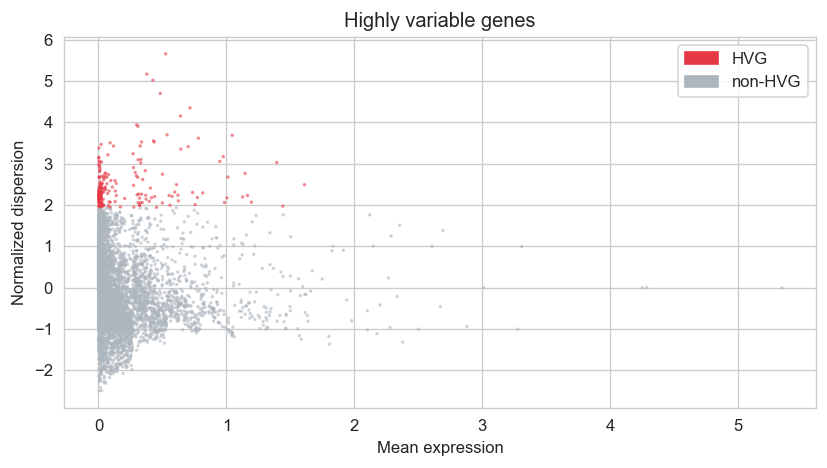

In [9]:
# --- Identify highly variable genes ---
hvg_records = spatialrs.highly_variable_genes(
    lognormed.astype(np.float64), genes_filt, n_top_genes=200, n_bins=20
)
df_hvg = pd.DataFrame(hvg_records)
print(f'HVGs selected: {df_hvg["highly_variable"].sum()}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(
    df_hvg['mean'], df_hvg['dispersion_norm'],
    c=df_hvg['highly_variable'].map({True: '#e63946', False: '#adb5bd'}),
    s=4, alpha=0.6, linewidths=0
)
ax.set_xlabel('Mean expression')
ax.set_ylabel('Normalized dispersion')
ax.set_title('Highly variable genes')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#e63946', label='HVG'), Patch(color='#adb5bd', label='non-HVG')])
plt.tight_layout()
plt.show()

## 3. Spatial graph QC — choosing the radius

We use the pre-processed `adata.X` and its existing annotations for the rest of the analysis.

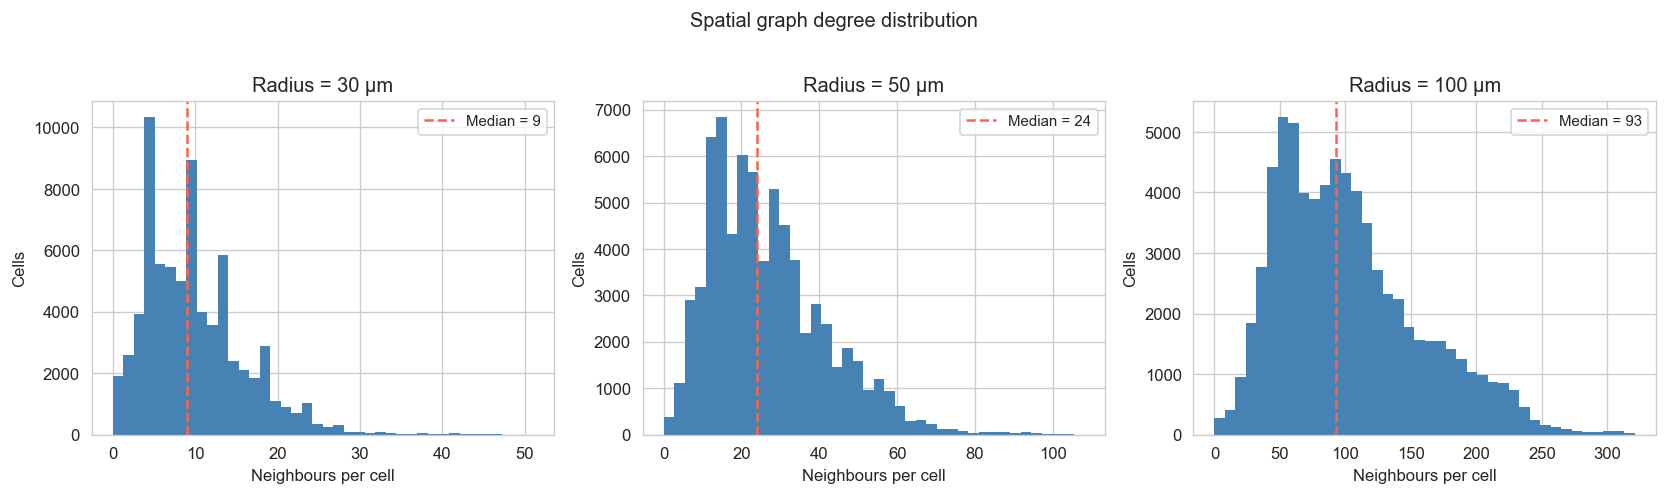

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, radius in zip(axes, [30, 50, 100]):
    stats = pd.DataFrame(spatialrs.graph_stats(coords, barcodes, radius=float(radius)))
    ax.hist(stats['n_neighbors'], bins=40, color='steelblue', edgecolor='none')
    ax.set_title(f'Radius = {radius} µm')
    ax.set_xlabel('Neighbours per cell')
    ax.set_ylabel('Cells')
    med = stats['n_neighbors'].median()
    ax.axvline(med, color='tomato', linestyle='--', label=f'Median = {med:.0f}')
    ax.legend(fontsize=9)

plt.suptitle('Spatial graph degree distribution', y=1.02)
plt.tight_layout()
plt.show()

# → radius=50 gives ~10-30 neighbours per cell across both samples; good balance.

## 4. Cell-type interaction enrichment

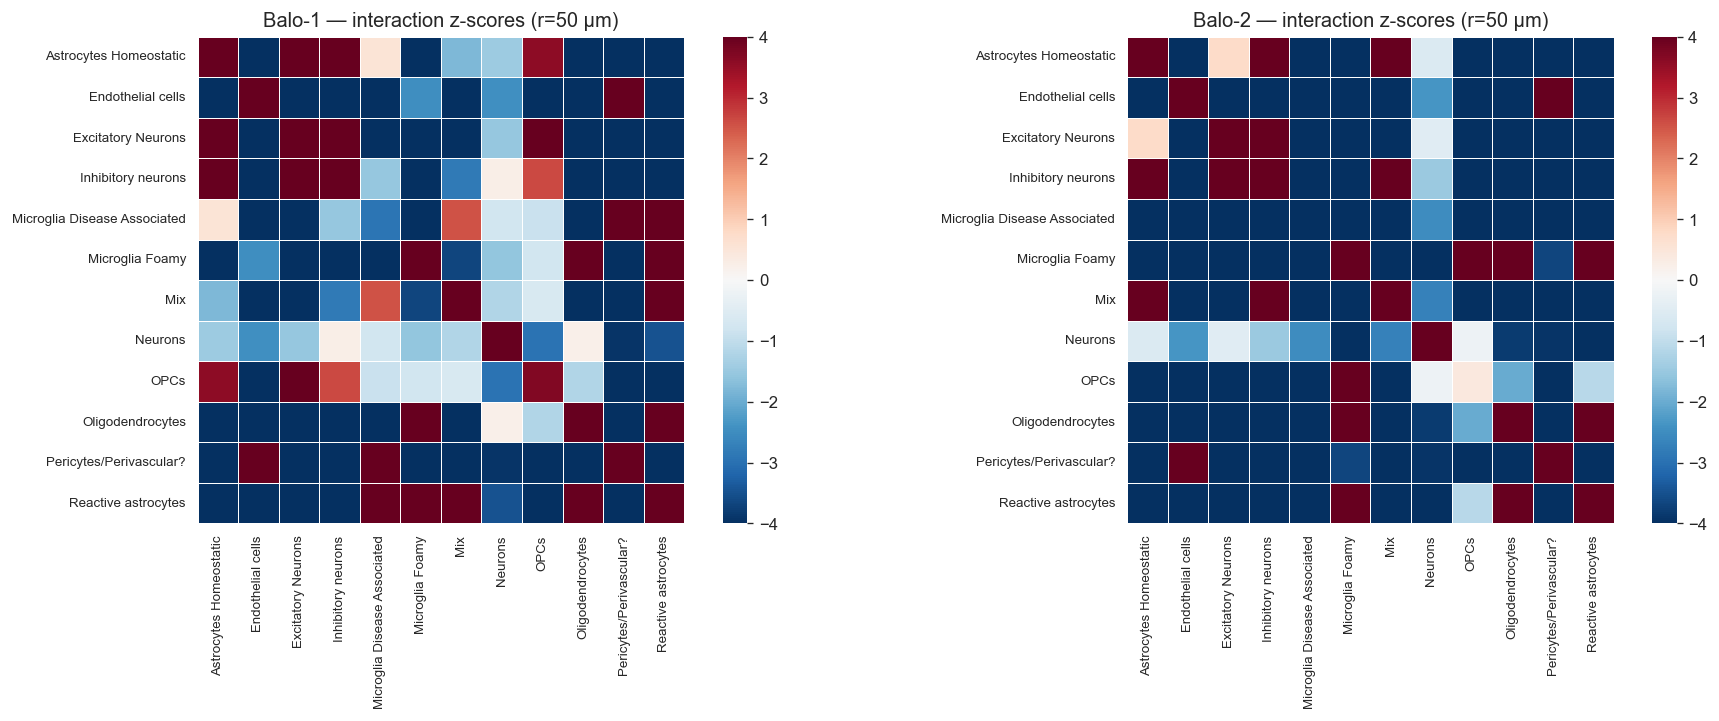

In [11]:
RADIUS = 50.0
N_PERMS = 500

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, sample in zip(axes, ['Balo-1', 'Balo-2']):
    m = mask[sample]
    idx = np.where(m)[0]
    c_s = coords[idx]
    b_s = [barcodes[i] for i in idx]
    ct_s = [cell_types[i] for i in idx]

    df_int = pd.DataFrame(spatialrs.interaction_stats(
        c_s, b_s, ct_s, RADIUS, n_perms=N_PERMS, group=sample
    ))

    # Pivot z-scores to a symmetric matrix
    all_types = sorted(set(df_int['cell_type_a']) | set(df_int['cell_type_b']))
    mat = pd.DataFrame(0.0, index=all_types, columns=all_types)
    for _, row in df_int.iterrows():
        mat.loc[row['cell_type_a'], row['cell_type_b']] = row['z_score']
        mat.loc[row['cell_type_b'], row['cell_type_a']] = row['z_score']

    sns.heatmap(
        mat, ax=ax, cmap='RdBu_r', center=0, vmin=-4, vmax=4,
        square=True, linewidths=0.4,
        xticklabels=True, yticklabels=True
    )
    ax.set_title(f'{sample} — interaction z-scores (r={RADIUS:.0f} µm)')
    ax.tick_params(axis='x', rotation=90, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.show()

## 5. Neighbourhood composition

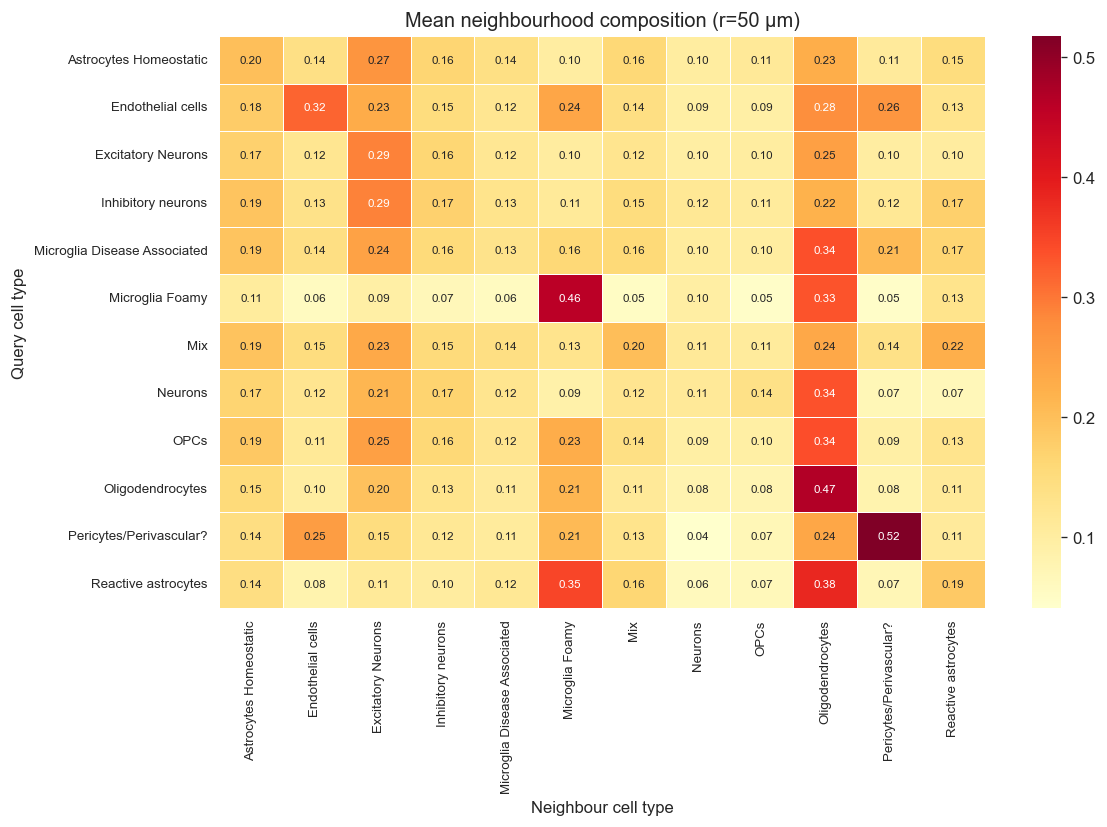

In [12]:
comp_records = []
for sample in ['Balo-1', 'Balo-2']:
    m = mask[sample]
    idx = np.where(m)[0]
    comp_records += spatialrs.neighborhood_composition(
        coords[idx], [barcodes[i] for i in idx],
        [cell_types[i] for i in idx], RADIUS, group=sample
    )

df_comp = pd.DataFrame(comp_records)

# Add queried cell's own type
bc_to_type = dict(zip(barcodes, cell_types))
df_comp['query_type'] = df_comp['cell_i'].map(bc_to_type)

# Mean composition per (query_type, neighbour_type)
pivot = (
    df_comp.groupby(['query_type', 'cell_type'])['fraction']
    .mean()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, ax=ax, cmap='YlOrRd', linewidths=0.3, annot=True, fmt='.2f', annot_kws={'size': 7})
ax.set_title(f'Mean neighbourhood composition (r={RADIUS:.0f} µm)')
ax.set_xlabel('Neighbour cell type')
ax.set_ylabel('Query cell type')
ax.tick_params(axis='x', rotation=90, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.show()

## 6. Moran's I — spatial autocorrelation of scVI components

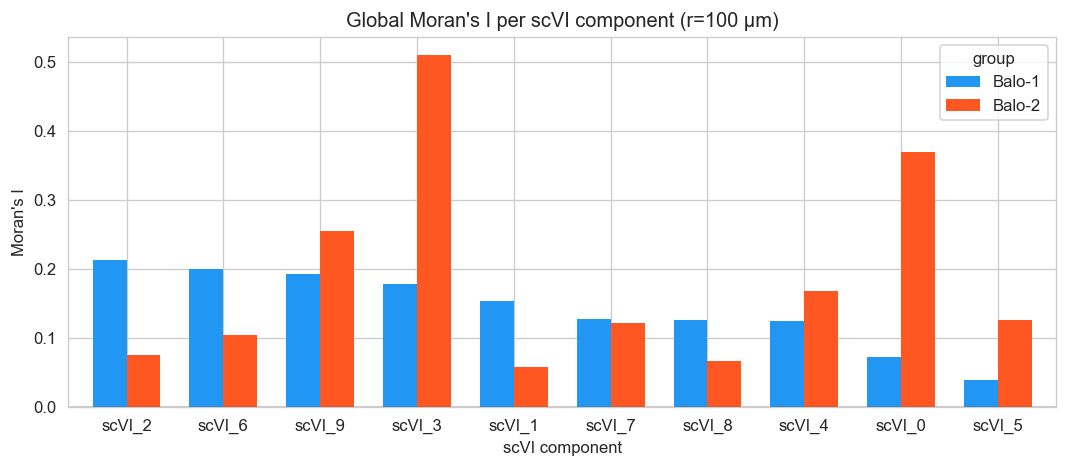

          moran_i     z_score
feature                      
scVI_3   0.344921  419.250651
scVI_9   0.224268  257.000759
scVI_0   0.221437  277.789939
scVI_6   0.153141  161.383327
scVI_4   0.146480  168.065254
scVI_2   0.144640  147.624800
scVI_7   0.124939  139.030880
scVI_1   0.106840  109.609939
scVI_8   0.096831  102.139261
scVI_5   0.082816  101.455190


In [13]:
MORAN_RADIUS = 100.0
feature_names = [f'scVI_{i}' for i in range(scvi.shape[1])]

morans_records = []
for sample in ['Balo-1', 'Balo-2']:
    m = mask[sample]
    idx = np.where(m)[0]
    morans_records += spatialrs.morans(
        coords[idx], scvi[idx], feature_names,
        radius=MORAN_RADIUS, group=sample
    )

df_morans = pd.DataFrame(morans_records)

fig, ax = plt.subplots(figsize=(9, 4))
df_pivot = df_morans.pivot(index='feature', columns='group', values='moran_i')
df_pivot.sort_values('Balo-1', ascending=False).plot(
    kind='bar', ax=ax, color=['#2196F3', '#FF5722'], edgecolor='none', width=0.7
)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('scVI component')
ax.set_ylabel("Moran's I")
ax.set_title(f"Global Moran's I per scVI component (r={MORAN_RADIUS:.0f} µm)")
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print(df_morans.groupby('feature')[['moran_i', 'z_score']].mean().sort_values('moran_i', ascending=False))

## 7. NMF on highly variable genes

In [14]:
# Use the pre-existing HVG flag from the h5ad (200 genes)
hvg_flag = adata.var['highly_variable'].values
expr_hvg = adata.X[:, hvg_flag]
if sp.issparse(expr_hvg):
    expr_hvg = expr_hvg.toarray()
expr_hvg = np.asarray(expr_hvg).astype(np.float64)  # ensure dense float64
genes_hvg = list(adata.var_names[hvg_flag])

print(f'NMF input: {expr_hvg.shape}, dtype={expr_hvg.dtype}')

NMF input: (71721, 200), dtype=float64


W: (71721, 12), H: (12, 200)
Converged in 200 iterations, final error = 264.0013


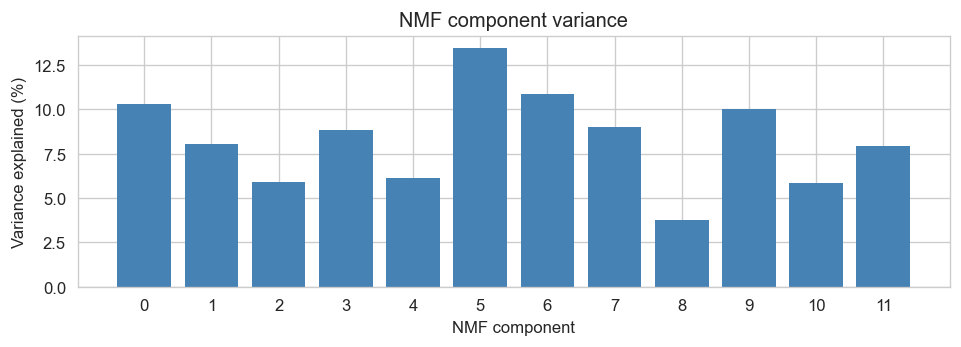

In [15]:
N_COMPONENTS = 12

nmf_result = spatialrs.nmf_factorize(
    expr_hvg, barcodes, genes_hvg,
    n_components=N_COMPONENTS, max_iter=200, seed=42
)

W = nmf_result['W']  # N × K  (cell loadings)
H = nmf_result['H']  # K × G  (gene loadings)

print(f'W: {W.shape}, H: {H.shape}')
print(f'Converged in {nmf_result["n_iter"]} iterations, final error = {nmf_result["final_error"]:.4f}')

# Variance explained per component
comp_var = nmf_result['component_variances']
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(N_COMPONENTS), [v * 100 for v in comp_var], color='steelblue', edgecolor='none')
ax.set_xlabel('NMF component')
ax.set_ylabel('Variance explained (%)')
ax.set_title('NMF component variance')
ax.set_xticks(range(N_COMPONENTS))
plt.tight_layout()
plt.show()

In [16]:
# Top genes per component
for k in range(N_COMPONENTS):
    top_idx = H[k].argsort()[::-1][:5]
    top_genes = [genes_hvg[i] for i in top_idx]
    print(f'NMF {k:2d}: {"  ".join(top_genes)}')

NMF  0: SPP1  CNP  APOD  MCL1  SLC1A2
NMF  1: CD74  APOC1  HLA-DRA  GPNMB  SERPINE1
NMF  2: VIM  GPNMB  SOCS3  APOC1  LYZ
NMF  3: MCL1  EGR3  CSF3R  C5AR1  FCGR3B
NMF  4: AQP4  GJA1  FGFR3  GFAP  HLA-DRA
NMF  5: GFAP  APOC1  GPNMB  SERPINE1  CXCR4
NMF  6: CNP  ADAMTS1  SLC2A1  HERC2  GFAP
NMF  7: SLC1A2  FGFR3  GJA1  PDGFRB  SLC2A1
NMF  8: SERPINA3  GFAP  CCN1  CDKN1A  EMP1
NMF  9: APOD  GPR17  IGFBP2  CCN1  FRZB
NMF 10: NR4A1  CDKN1A  HERC2  EPAS1  CLDN5
NMF 11: EGR3  SPP1  CCL4  EGR2  SERPINE1


## 8. Spatial compartment detection — multiscale aggregation + GMM

Raw NMF factors cluster **cell types**. To find **tissue compartments** (like CellCharter),
we first aggregate each cell's NMF embedding over its spatial neighbourhood at multiple radii
(0-hop = self, 50 µm, 150 µm, 300 µm), then cluster on the stacked multi-scale features.
The neighbourhood context swamps the single-cell identity signal, so the GMM must explain
spatial structure to lower its BIC.

In [19]:
N_NICHES = 10
RADII    = [50.0, 150.0, 300.0]   # µm — neighbourhood scales

# ── 1. Multiscale aggregation ────────────────────────────────────────────────
# Shape: (N, D × 4)  = 12 components × 4 scales (self + 3 radii)
W_ms = spatialrs.multiscale_aggregate(
    coords, barcodes,
    W.astype(np.float64),
    radii=RADII,
    include_self=True,
    weighting="gaussian",
)
n_scales = W_ms.shape[1] // N_COMPONENTS
print(f"Multiscale feature matrix: {W_ms.shape}  ({N_COMPONENTS} dims x {n_scales} scales)")

# ── 2. GMM on multi-scale features → spatial compartments ────────────────────
gmm_result = spatialrs.gmm_cluster(
    W_ms, barcodes,
    n_components=N_NICHES, max_iter=200, seed=42
)

niche_labels = np.array(gmm_result["labels"])
bic_ms  = gmm_result["bic"]
aic_ms  = gmm_result["aic"]
nit_ms  = gmm_result["n_iter"]
print(f"BIC={bic_ms:.1f}  AIC={aic_ms:.1f}  n_iter={nit_ms}")

# Compare with single-scale GMM (raw W) as a sanity check
gmm_raw = spatialrs.gmm_cluster(
    W.astype(np.float64), barcodes,
    n_components=N_NICHES, max_iter=200, seed=42
)
bic_raw = gmm_raw["bic"]
print(f"Single-scale BIC={bic_raw:.1f}  (lower = better fit to spatial structure)")

# Niche sizes
unique, counts = np.unique(niche_labels, return_counts=True)
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(unique, counts, color="mediumpurple", edgecolor="none")
ax.set_xlabel("Niche / compartment")
ax.set_ylabel("Cells")
ax.set_title("Multiscale GMM compartment sizes")
ax.set_xticks(unique)
plt.tight_layout()
plt.show()

AttributeError: module 'spatialrs' has no attribute 'multiscale_aggregate'

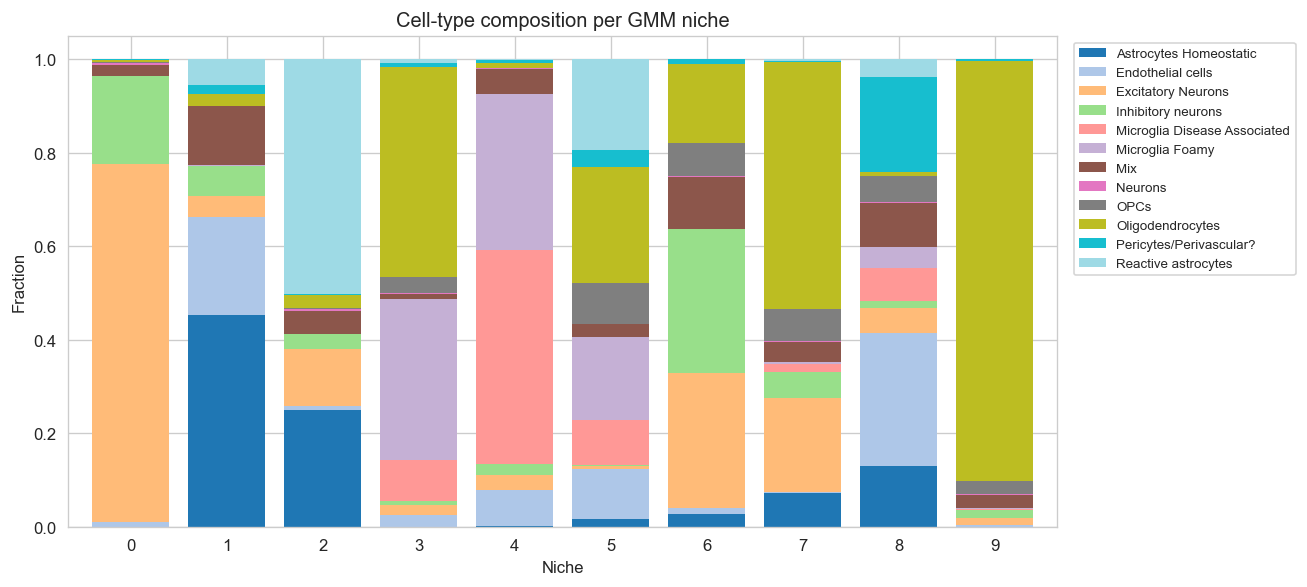

In [ ]:
# Niche × cell-type composition
df_niches = pd.DataFrame({
    'niche': niche_labels,
    'cell_type': cell_types
})
niche_comp = (
    df_niches.groupby(['niche', 'cell_type'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda r: r / r.sum(), axis=1)
)

fig, ax = plt.subplots(figsize=(11, 5))
niche_comp.plot(kind='bar', ax=ax, stacked=True, colormap='tab20', edgecolor='none', width=0.8)
ax.set_xlabel('Niche')
ax.set_ylabel('Fraction')
ax.set_title('Cell-type composition per GMM niche')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 9. Spatial maps

/var/folders/5b/5bpdw2nj10d6gxym7gcl01hh0000gp/T/ipykernel_79361/2758610111.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_niches = plt.cm.get_cmap('tab10', N_NICHES)
/var/folders/5b/5bpdw2nj10d6gxym7gcl01hh0000gp/T/ipykernel_79361/2758610111.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_types  = plt.cm.get_cmap('tab20', len(set(cell_types)))


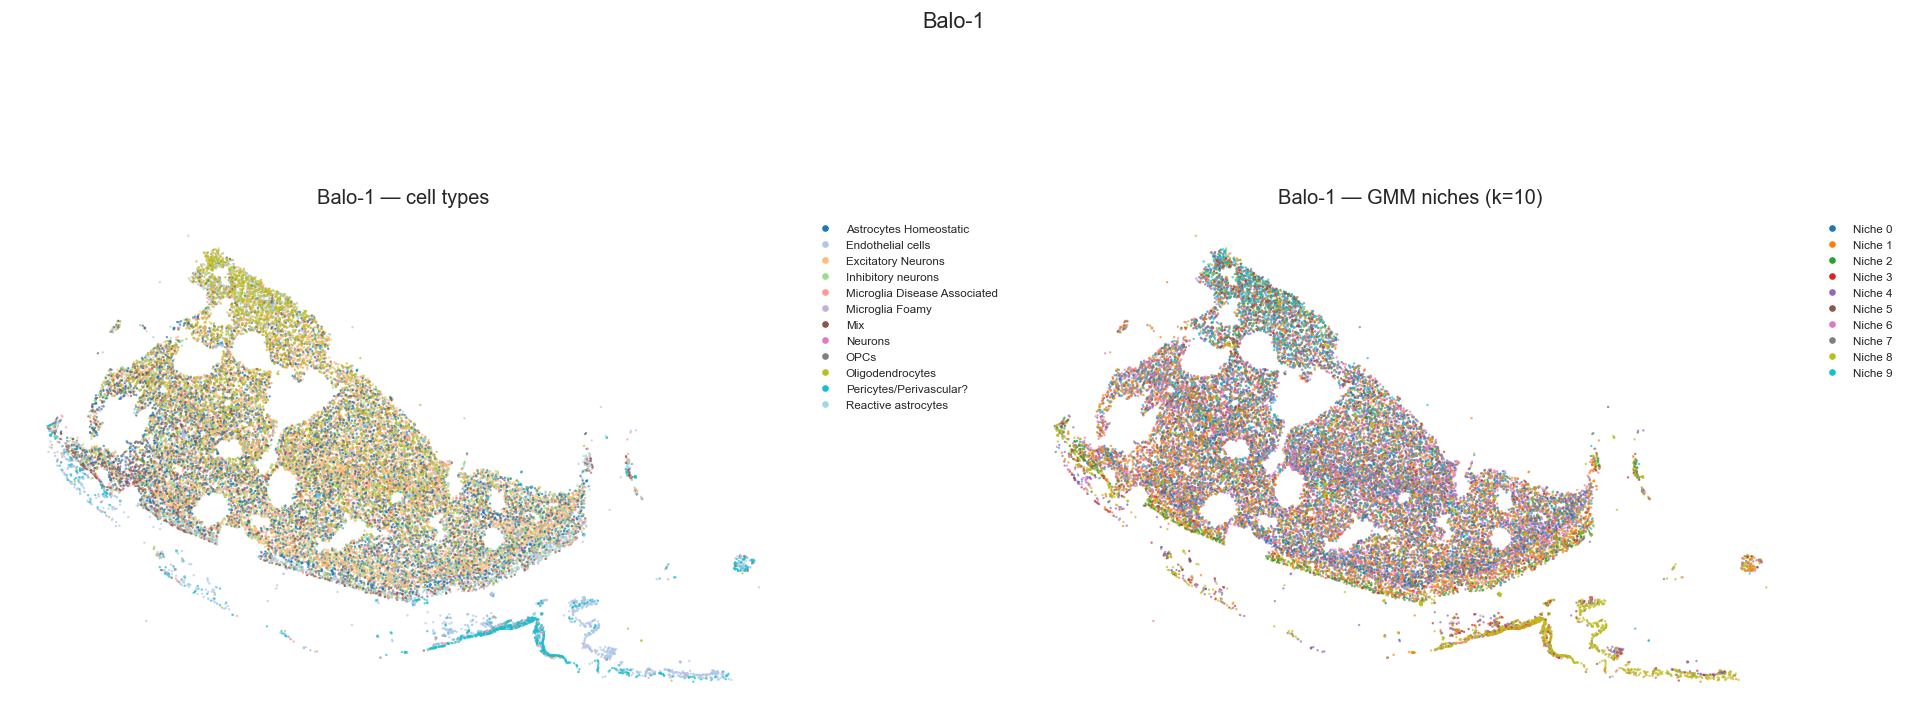

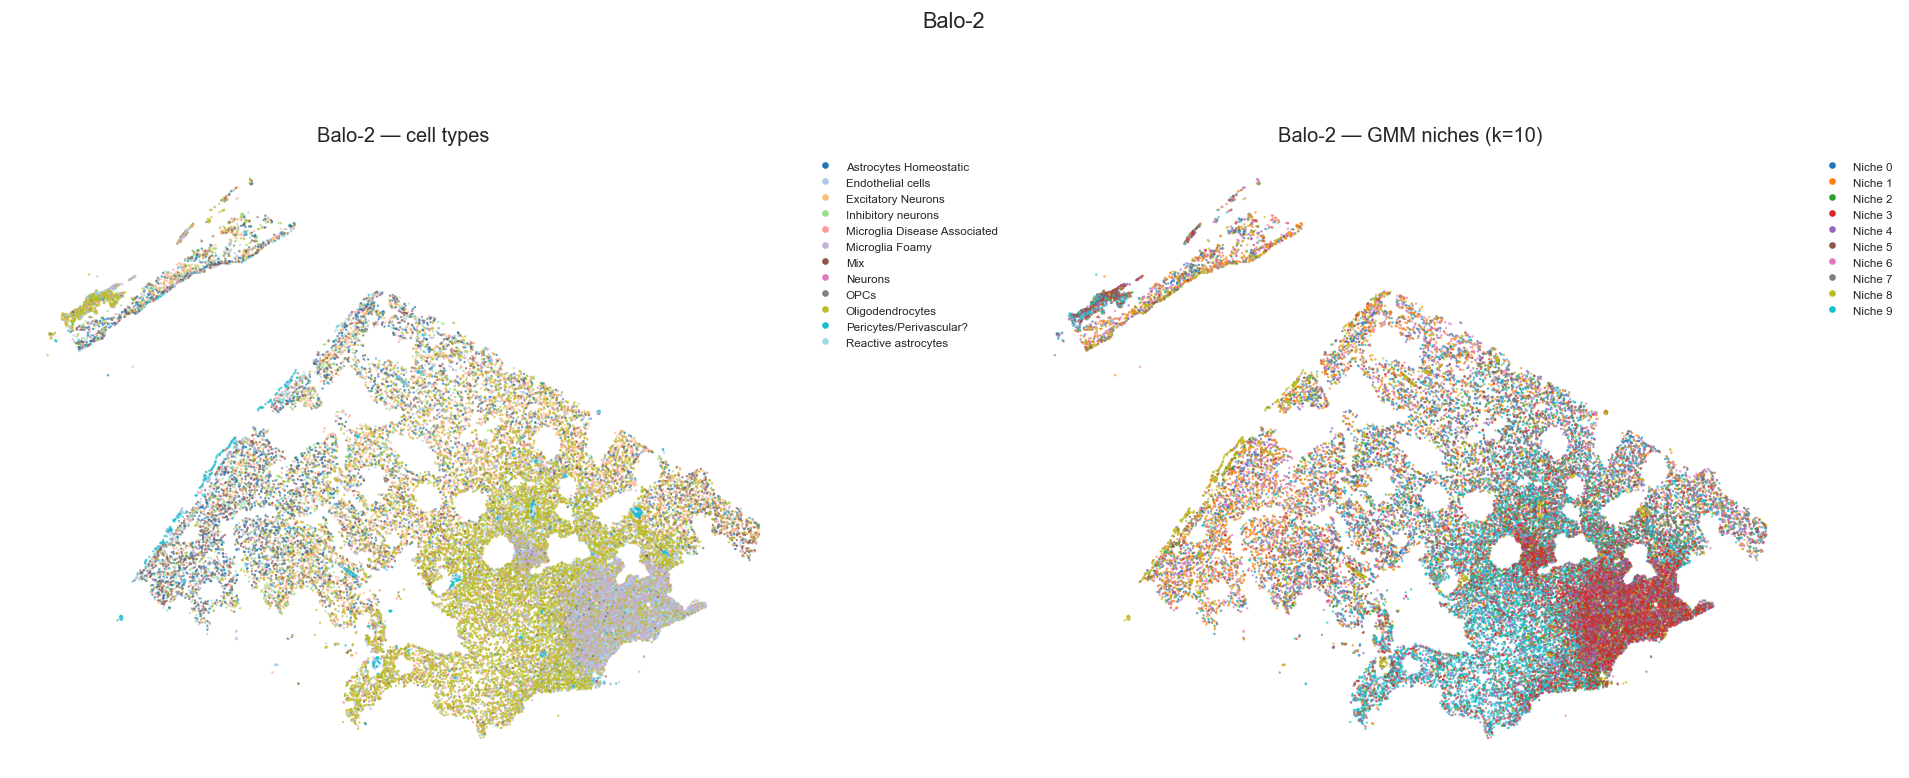

In [ ]:
cmap_niches = plt.cm.get_cmap('tab10', N_NICHES)
cmap_types  = plt.cm.get_cmap('tab20', len(set(cell_types)))
type_list   = sorted(set(cell_types))
type_to_idx = {t: i for i, t in enumerate(type_list)}

for sample in ['Balo-1', 'Balo-2']:
    m = mask[sample]
    idx = np.where(m)[0]
    c = coords[idx]
    ct_idx = [type_to_idx[cell_types[i]] for i in idx]
    ni = niche_labels[idx]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Cell types
    sc0 = axes[0].scatter(c[:, 0], c[:, 1], c=ct_idx, cmap='tab20',
                          s=2, alpha=0.7, linewidths=0, rasterized=True)
    axes[0].set_title(f'{sample} — cell types')
    axes[0].set_aspect('equal')
    axes[0].axis('off')
    handles = [plt.Line2D([0],[0], marker='o', color='w',
                          markerfacecolor=cmap_types(type_to_idx[t]), markersize=5, label=t)
               for t in type_list]
    axes[0].legend(handles=handles, bbox_to_anchor=(1.01, 1), loc='upper left',
                   fontsize=7, frameon=False)

    # GMM niches
    axes[1].scatter(c[:, 0], c[:, 1], c=ni, cmap='tab10', vmin=0, vmax=N_NICHES - 1,
                    s=2, alpha=0.7, linewidths=0, rasterized=True)
    axes[1].set_title(f'{sample} — GMM niches (k={N_NICHES})')
    axes[1].set_aspect('equal')
    axes[1].axis('off')
    niche_handles = [plt.Line2D([0],[0], marker='o', color='w',
                                markerfacecolor=cmap_niches(n), markersize=5, label=f'Niche {n}')
                     for n in range(N_NICHES)]
    axes[1].legend(handles=niche_handles, bbox_to_anchor=(1.01, 1), loc='upper left',
                   fontsize=7, frameon=False)

    plt.suptitle(sample, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

## 10. Compare spatialrs GMM with existing MANA niches

spatialrs GMM vs MANA gmm_mana_10  |  ARI = 0.164  NMI = 0.260


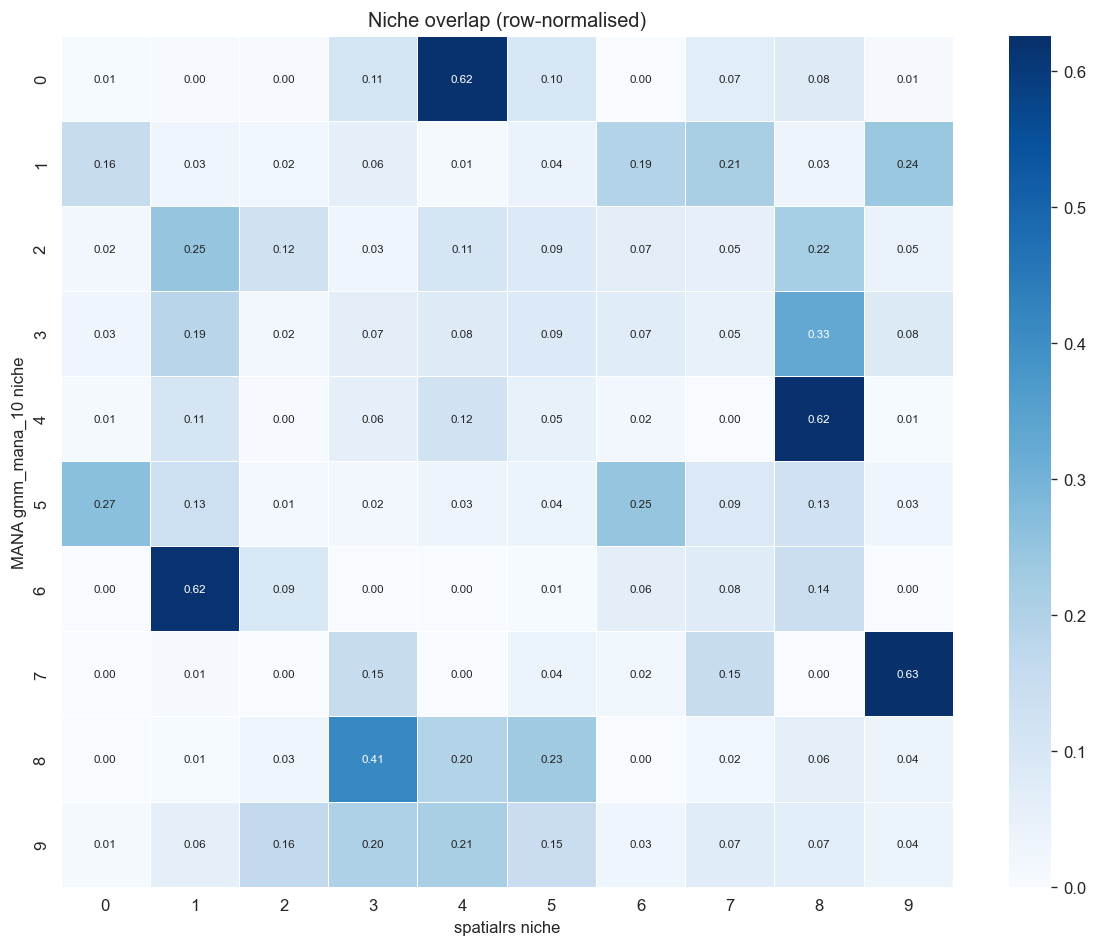

In [ ]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

mana_labels = adata.obs['gmm_mana_10'].astype(int).values

ari = adjusted_rand_score(mana_labels, niche_labels)
nmi = normalized_mutual_info_score(mana_labels, niche_labels)
print(f'spatialrs GMM vs MANA gmm_mana_10  |  ARI = {ari:.3f}  NMI = {nmi:.3f}')

# Confusion / co-occurrence
from pandas import crosstab
ct_mat = crosstab(mana_labels, niche_labels, normalize='index')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(ct_mat, ax=ax, cmap='Blues', annot=True, fmt='.2f',
            annot_kws={'size': 7}, linewidths=0.3)
ax.set_xlabel('spatialrs niche')
ax.set_ylabel('MANA gmm_mana_10 niche')
ax.set_title('Niche overlap (row-normalised)')
plt.tight_layout()
plt.show()

## 11. Write results back to AnnData (optional)

In [ ]:
# Add NMF and GMM results back into adata
adata.obsm["X_spatialrs_nmf_w"]          = W
adata.obsm["X_spatialrs_nmf_h"]          = H.T          # N × K
adata.obsm["X_spatialrs_nmf_multiscale"] = W_ms         # N × (K × n_scales)
adata.obs["spatialrs_niche"]              = pd.Categorical(niche_labels.astype(str))
adata.obs["spatialrs_niche_raw"]         = pd.Categorical(
    np.array(gmm_raw["labels"]).astype(str)
)  # single-scale for comparison

print(adata)

# Uncomment to save:
# adata.write_h5ad("baloMS_with_spatialrs.h5ad")

ValueError: Value passed for key 'X_spatialrs_nmf_h' is of incorrect shape. Values of obsm must match dimensions ('obs',) of parent. Value had shape (200,) while it should have had (71721,).

In [ ]:
adata

AnnData object with n_obs × n_vars = 71721 × 5101
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'sample_id', 'n_genes_by_counts', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_1.5', 'leiden_2', 'gmm_mana_5', 'gmm_mana_8', 'gmm_mana_10', 'gmm_mana_12', 'gmm_mana_15', 'gmm_mana_20', 'leiden_0.5_names', 'leiden_1_names', 'leiden_2_names', 'leiden_2_names_sub'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'ACSL1_continuous', 'APOE_continuous', 'CCL5_continuous', 'CHIT1_continuous', 'PADI4_continuous', 'SPP1_continuous', 'X_mana_gauss_params', 'gmm_mana_10_colors', 'gmm_mana_15_colors', 'gmm_mana_20_colors', 'gmm_m